In [1]:
%matplotlib widget

In [2]:
import logging
import os
import pickle
import random

import matplotlib.pyplot as plt  # noqa
import numpy as np  # noqa
from sklearn.ensemble import RandomForestClassifier  # noqa

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor
from xasml.models.io import read_from_h5
from xasml.models.metrics import calculate_accuracies, display_metrics

In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("xasml").setLevel(logging.DEBUG)
logger = logging.getLogger("xasml.experimental_predictions")

plt.style.use("stylelib/presentation.mplstyle")

In [4]:
# Define some constants.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ELEMENT = "Fe"
JOB = "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN = -10 + ENERGY_SHIFT
ENERGY_MAX = 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"  # Z-score fails when adding noise.
OUTLIER_THRESHOLD = 4
PREFIX = os.path.join("figures", "experimental_predictions")
EXTENSION = "pdf"
DPI = 300
THRESHOLD = 0.5  # CNN decision threshold (sigmoid output).

# Read data from file.
X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)

# Create a processor object.
processor = Processor(X, y, metas=metas)

In [5]:
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.normalize(method=NORMALIZATION, reference=energies)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

2026-08-17 22:58:09,000 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:58:09,000 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:58:11,897 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:58:11,898 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:58:11,898 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:58:15,352 - xasml.models.data - DEBUG - y_train: (2187,)


2026-08-17 22:58:15,353 - xasml.models.data - DEBUG - metas_train: 2187


2026-08-17 22:58:15,353 - xasml.models.data - DEBUG - X_test: (547, 701)


2026-08-17 22:58:15,353 - xasml.models.data - DEBUG - y_test: (547,)


2026-08-17 22:58:15,353 - xasml.models.data - DEBUG - metas_test: 547


2026-08-17 22:58:17,095 - xasml.models.metrics - INFO - Balanced accuracy: 92.3%


2026-08-17 22:58:17,096 - xasml.models.metrics - INFO -   O:6: 96.6%


2026-08-17 22:58:17,096 - xasml.models.metrics - INFO -   T:4: 88.1%


2026-08-17 22:58:17,096 - xasml.models.metrics - DEBUG - Evaluating predictions on 547 samples across 2 classes.


2026-08-17 22:58:17,099 - xasml.models.metrics - INFO - Balanced accuracy: 92.3%


2026-08-17 22:58:17,099 - xasml.models.metrics - INFO -   O:6: 96.6%


2026-08-17 22:58:17,099 - xasml.models.metrics - INFO -   T:4: 88.1%


2026-08-17 22:58:17,101 - xasml.models.metrics - INFO - Accuracy: 94.1%


2026-08-17 22:58:17,101 - xasml.models.metrics - INFO - F1 score: 94.1%


{'accuracy': 0.9414990859232175,
 'balanced': 0.9234989950074564,
 np.str_('O:6'): 0.9664948453608248,
 np.str_('T:4'): 0.8805031446540881}

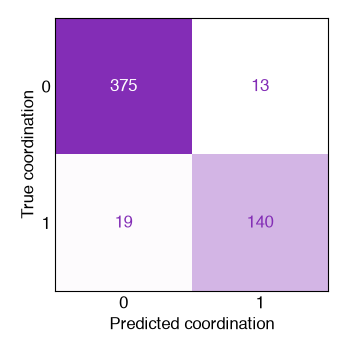

In [6]:
model = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
model.fit(processor.X_train, processor.y_train)
y_pred = model.predict(processor.X_test)
calculate_accuracies(processor.y_test, y_pred)
display_metrics(processor.y_test, y_pred)

In [7]:
# Read the experimental data and shape it to the same format as the calculated data.
path = resource_path("xasml:datasets/experimental/normalized_experimental_data.pkl")
with open(path, "rb") as f:
    data = pickle.load(f)

X_expt, y_expt = [], []
for material in data:
    x, y, symmetry = data[material]
    yi = np.interp(energies, x, y)
    yi = yi / np.trapezoid(yi, energies)
    X_expt.append(yi)
    y_expt.append(symmetry)

X_expt = np.array(X_expt)
y_expt = np.array(y_expt)
materials = list(data.keys())

Saved experimental_spectra.pdf


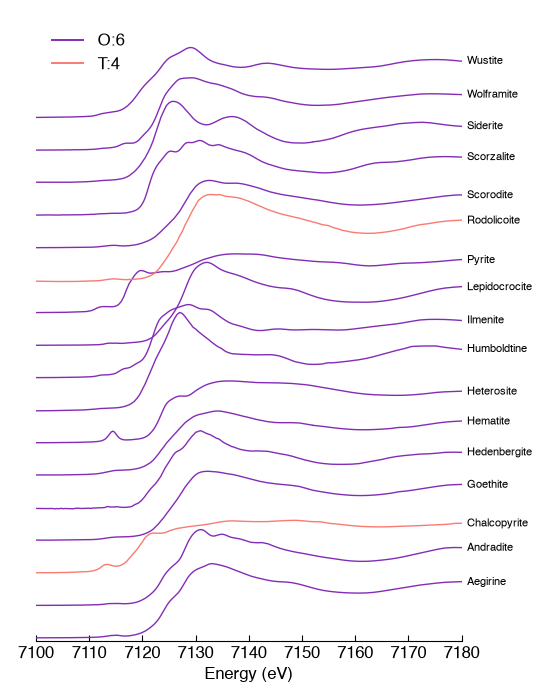

In [8]:
# Offset stack of the experimental reference spectra (Figure: experimental_spectra.pdf).
# Spectra are the edge-step-normalised experimental data, ordered alphabetically
# and vertically offset to be distinguishable; the y axis is therefore arbitrary.
OFFSET = 0.6
CLASS_COLORS = {"O:6": "#832db6", "T:4": "#f97b72"}

fig, ax = plt.subplots(figsize=(5.5, 7.0))
for i, material in enumerate(sorted(data)):
    x, yi, symmetry = data[material]
    ax.plot(x, yi + i * OFFSET, lw=1.0, color=CLASS_COLORS[symmetry])
    right_value = np.interp(7179.0, x, yi)
    ax.text(7181.0, right_value + i * OFFSET, material, va="center", ha="left", fontsize=8)

handles = [
    plt.Line2D([0], [0], color=CLASS_COLORS[s], lw=1.4, label=s) for s in ["O:6", "T:4"]
]
ax.legend(handles=handles, loc="upper left", frameon=False)
ax.set_xlim(7100, 7180)
ax.set_ylim(bottom=-0.05)
ax.set_xlabel("Energy (eV)")
ax.set_yticks([])
ax.tick_params(direction="in", length=4, top=False, right=False)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join("figures", "experimental_spectra.pdf"), dpi=DPI, bbox_inches="tight")
print("Saved experimental_spectra.pdf")


## Predictions on experimental data

Each model is trained (RF) or loaded (CNN) from the theoretical data and applied to the experimental spectra, including the perturbation-augmented variants.

In [9]:
# Noise-augmented RF, matched to the RF failure mode.
# Re-run the pipeline so the cell is self-contained, then augment two thirds of
# the training set with Poisson noise (SNR 10-250).
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)
energies_grid = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies_grid)
energies_grid = energies_grid[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)
processor.augment(
    energies=energies_grid,
    fraction=2 / 3,
    snr_range=(10, 250),
    noise_reference_intensity=FE_REFERENCE_MBARN,
    shift_range=None,
    normalization=NORMALIZATION,
    random_seed=RANDOM_SEED,
)
rf_augmented = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
rf_augmented.fit(processor.X_train, processor.y_train)

2026-08-17 22:58:17,394 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:58:17,395 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:58:20,457 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:58:20,458 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:58:20,458 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:58:23,588 - xasml.models.data - DEBUG - X_test: (547, 701)


2026-08-17 22:58:23,588 - xasml.models.data - DEBUG - y_test: (547,)


2026-08-17 22:58:23,588 - xasml.models.data - DEBUG - metas_test: 547


2026-08-17 22:58:23,648 - xasml.models.data - INFO - Augmented 'train' subset with 1458 samples (shift: 0, noise: 1458, self-absorption: 0). Total: 3645 samples.


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [10]:
# Load the CNN checkpoints (trained on the theoretical data; never retrained here).
os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"
import keras  # noqa: E402
from sklearn.preprocessing import LabelEncoder  # noqa: E402

label_encoder = LabelEncoder()
label_encoder.fit(LABELS)  # O:6 -> 0, T:4 -> 1.

cnn = keras.models.load_model("cnn_classifier.keras", compile=False)
cnn_augmented = keras.models.load_model("cnn_classifier_augmented.keras", compile=False)


def cnn_predict(network, features):
    probabilities = network.predict(features, verbose=0).ravel()
    indices = (probabilities >= THRESHOLD).astype(int)
    return label_encoder.inverse_transform(indices)

In [11]:
predictions = {
    "True": y_expt,
    "RF": model.predict(X_expt),
    "RF (aug)": rf_augmented.predict(X_expt),
    "CNN": cnn_predict(cnn, X_expt),
    "CNN (aug)": cnn_predict(cnn_augmented, X_expt),
}

# Print an aligned comparison of the predictions per material.
columns = list(predictions)
print(f"{'Material':<18}" + "".join(f"{c:>10}" for c in columns))
for i, material in enumerate(materials):
    print(f"{material:<18}" + "".join(f"{predictions[c][i]:>10}" for c in columns))

Material                True        RF  RF (aug)       CNN CNN (aug)
Chalcopyrite             T:4       T:4       T:4       T:4       T:4
Wustite                  O:6       T:4       T:4       T:4       T:4
Andradite                O:6       O:6       O:6       O:6       O:6
Siderite                 O:6       O:6       O:6       O:6       O:6
Rodolicoite              T:4       O:6       O:6       O:6       O:6
Hedenbergite             O:6       O:6       O:6       O:6       O:6
Hematite                 O:6       T:4       T:4       T:4       O:6
Pyrite                   O:6       T:4       T:4       T:4       T:4
Scorodite                O:6       O:6       O:6       O:6       O:6
Wolframite               O:6       O:6       O:6       O:6       O:6
Aegirine                 O:6       O:6       O:6       O:6       O:6
Humboldtine              O:6       O:6       O:6       O:6       O:6
Ilmenite                 O:6       O:6       O:6       O:6       O:6
Goethite                 O:6      

In [12]:
for name in ["RF", "RF (aug)", "CNN", "CNN (aug)"]:
    accuracies = calculate_accuracies(y_expt, predictions[name])
    logger.info(f"{name}: balanced accuracy {accuracies['balanced']:.1%}")

2026-08-17 22:58:30,064 - xasml.models.metrics - INFO - Balanced accuracy: 61.7%


2026-08-17 22:58:30,064 - xasml.models.metrics - INFO -   O:6: 73.3%


2026-08-17 22:58:30,064 - xasml.models.metrics - INFO -   T:4: 50.0%


2026-08-17 22:58:30,065 - xasml.experimental_predictions - INFO - RF: balanced accuracy 61.7%


2026-08-17 22:58:30,066 - xasml.models.metrics - INFO - Balanced accuracy: 61.7%


...

2026-08-17 22:58:30,069 - xasml.experimental_predictions - INFO - CNN: balanced accuracy 65.0%


2026-08-17 22:58:30,071 - xasml.models.metrics - INFO - Balanced accuracy: 65.0%


2026-08-17 22:58:30,071 - xasml.models.metrics - INFO -   O:6: 80.0%


2026-08-17 22:58:30,071 - xasml.models.metrics - INFO -   T:4: 50.0%


2026-08-17 22:58:30,071 - xasml.experimental_predictions - INFO - CNN (aug): balanced accuracy 65.0%
